In [1]:
from __future__ import print_function,division
from builtins import range

In [2]:
import matplotlib.pylab as plt
import numpy as np 
from scipy.stats import norm

In [3]:
np.random.seed(1)
NUM_TRIALS=2000
BANDIT_MEANS=[5,10,20]

In [98]:
class Bandit:
    def __init__(self,true_mean):
        self.true_mean=true_mean
        self.lambda_=1/4
        self.mean=5
        self.sum_x=0
        self.tau=1
        self.N=0
    
    def pull (self):
        return np.random.randn()/np.sqrt(self.tau)+self.true_mean
    
    def sample(self):
        return np.random.randn()/np.sqrt(self.lambda_) +self.mean
    
    def update(self,x):
        #self.mean = (self.tau *x + self.lambda_ *self.mean)/(self.lambda_ + self.tau)

        self.lambda_= self.tau+ self.lambda_
        self.sum_x +=x
        self.mean=(self.tau *self.sum_x)/self.lambda_
        self.N +=1
    

In [99]:
def plot(bandits,trial):
        x=np.linspace(-10,30,200)
        for b in bandits:
            y=norm.pdf(x,b.mean,np.sqrt(1/b.lambda_))
            plt.plot(x,y,label=f"real man: {b.true_mean:.4f}, num play={b.N}")
        plt.title(f"Bandit distribution after {trial} trails")
        plt.legend()
        plt.show()
            

In [104]:
def experiment():
    bandits=[Bandit(p) for p in BANDIT_MEANS]
        
    semple_points=[5,10,20,50,100,200,500,1000,1500,1999]
    rewards = np.zeros(NUM_TRIALS)
    for i in range (NUM_TRIALS):
        j=np.argmax([b.sample() for b in bandits])
        if i in semple_points:
            plot(bandits,i)
                
        x=bandits[j].pull()
        rewards[i]=x
        x=bandits[j].update(x)
    
    cumulative_average = np.cumsum(rewards)/(np.arange(NUM_TRIALS)+1)    
    print("total reward earned:",rewards.sum())
    print("overall win rate:",rewards.sum()/NUM_TRIALS)
    
    print("num times selected each bandit:",[b.N for b in bandits])
    
    plt.plot(cumulative_average)
    plt.plot(np.ones(NUM_TRIALS)*np.max(BANDIT_MEANS))
    plt.xscale('log')
    plt.show()
    

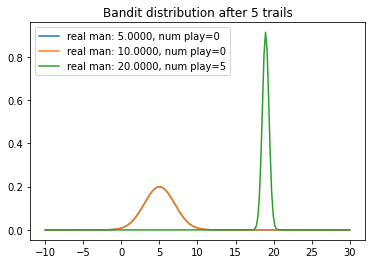

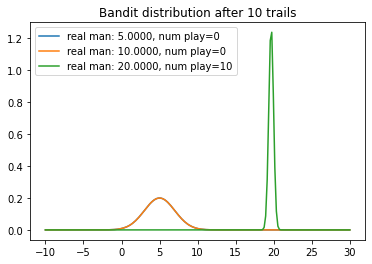

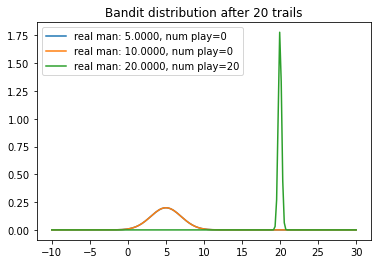

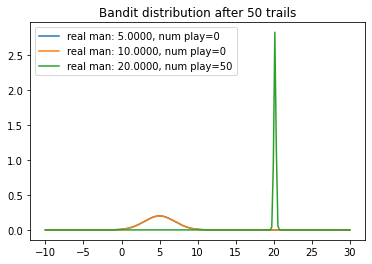

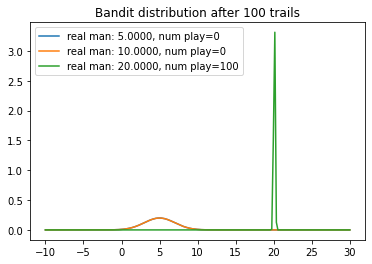

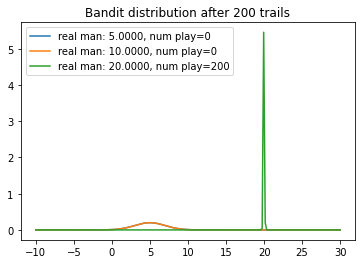

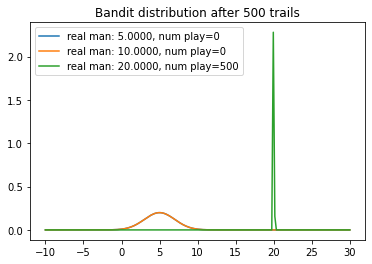

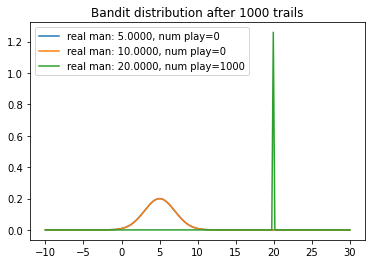

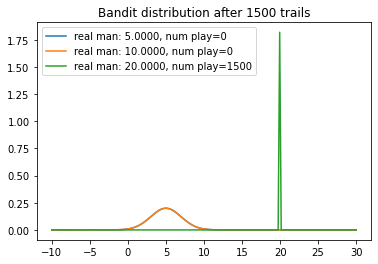

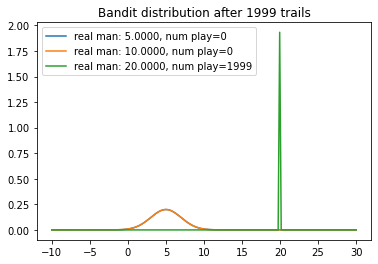

total reward earned: 39999.10637265249
overall win rate: 19.999553186326246
num times selected each bandit: [0, 0, 2000]


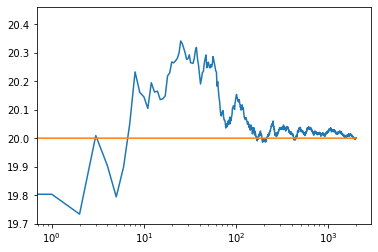

In [107]:
if __name__ =="__main__":
    experiment()